In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import torch
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [7]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="Cora", node_feature_type="PyG")

In [8]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 10,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2
  }

In [9]:
dataset = Planetoid(root ='tmp/Cora', name='Cora', split='full', num_train_per_class=20, num_val=500, num_test=1000)

In [10]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 1433
Number of num_classes : 7
Number of num_nodes : 2708
Number of num_edges : 10556


In [11]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [23]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        val_f1, val_acc = test(model, data, data.val_mask)
        test_f1, test_acc = test(model, data, data.test_mask)


        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 1 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))

    test_f1, test_acc,y_true, y_pred = test(model, data, data.test_mask, return_preds=True)
    
    #test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(5), yticklabels=range(5))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    
    return model, train_losses, val_f1s, test_f1s, training_time

In [14]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [15]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [16]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 0.1042, Val F1: 0.8491,Val Acc: 0.8600, Time: 0.01s
Test F1: 0.8595
Test Accuracy: 0.8730


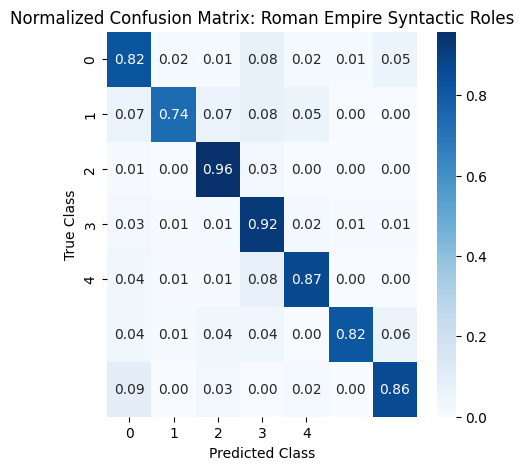

GCN results saved using PyG features.
Training Time 0.05503225326538086


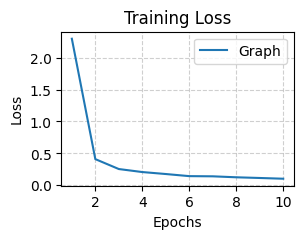

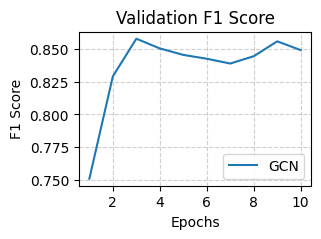

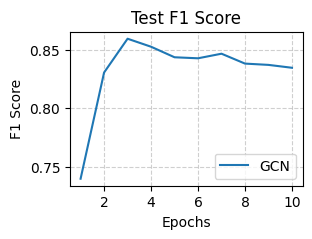

In [22]:
gcn_run()

In [24]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        model_name="GraphSAGE",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 001, Loss: 2.0811, Val F1: 0.4684,Val Acc: 0.6500, Time: 0.48s
Epoch: 002, Loss: 0.6979, Val F1: 0.8462,Val Acc: 0.8580, Time: 0.00s
Epoch: 003, Loss: 0.2732, Val F1: 0.8524,Val Acc: 0.8600, Time: 0.00s
Epoch: 004, Loss: 0.1851, Val F1: 0.8672,Val Acc: 0.8740, Time: 0.00s
Epoch: 005, Loss: 0.1363, Val F1: 0.8690,Val Acc: 0.8780, Time: 0.00s
Epoch: 006, Loss: 0.1037, Val F1: 0.8798,Val Acc: 0.8840, Time: 0.00s
Epoch: 007, Loss: 0.0825, Val F1: 0.8737,Val Acc: 0.8780, Time: 0.00s
Epoch: 008, Loss: 0.0669, Val F1: 0.8612,Val Acc: 0.8680, Time: 0.00s
Epoch: 009, Loss: 0.0559, Val F1: 0.8570,Val Acc: 0.8620, Time: 0.00s
Epoch: 010, Loss: 0.0443, Val F1: 0.8517,Val Acc: 0.8580, Time: 0.00s
Test F1: 0.8502
Test Accuracy: 0.8590


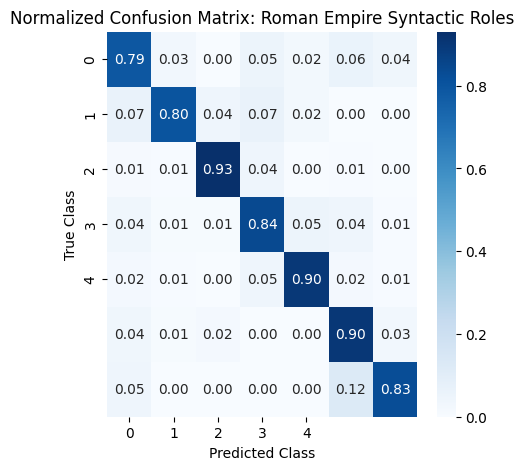

GRAPHSAGE results saved using PyG features.
Training Time 0.5206155776977539


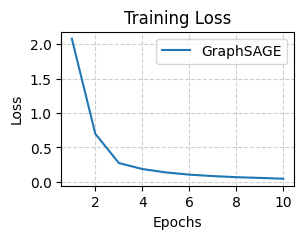

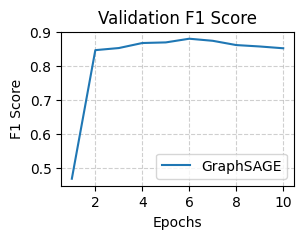

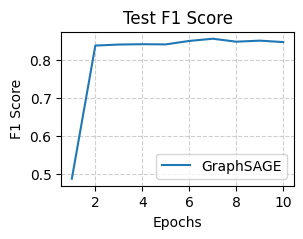

In [25]:
graphSage_run()

In [26]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GAT",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 001, Loss: 2.4210, Val F1: 0.2666,Val Acc: 0.3800, Time: 1.16s
Epoch: 002, Loss: 1.0652, Val F1: 0.7723,Val Acc: 0.8000, Time: 0.01s
Epoch: 003, Loss: 0.7335, Val F1: 0.7929,Val Acc: 0.8160, Time: 0.01s
Epoch: 004, Loss: 0.6121, Val F1: 0.8032,Val Acc: 0.8360, Time: 0.01s
Epoch: 005, Loss: 0.5099, Val F1: 0.8185,Val Acc: 0.8500, Time: 0.01s
Epoch: 006, Loss: 0.5132, Val F1: 0.8295,Val Acc: 0.8520, Time: 0.01s
Epoch: 007, Loss: 0.4452, Val F1: 0.8454,Val Acc: 0.8560, Time: 0.01s
Epoch: 008, Loss: 0.4276, Val F1: 0.8597,Val Acc: 0.8680, Time: 0.01s
Epoch: 009, Loss: 0.3948, Val F1: 0.8539,Val Acc: 0.8620, Time: 0.01s
Epoch: 010, Loss: 0.3653, Val F1: 0.8532,Val Acc: 0.8600, Time: 0.01s
Test F1: 0.8404
Test Accuracy: 0.8510


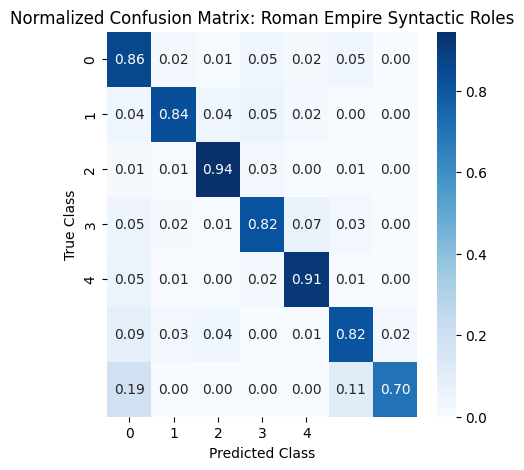

GAT results saved using PyG features.
Training Time 1.237694263458252


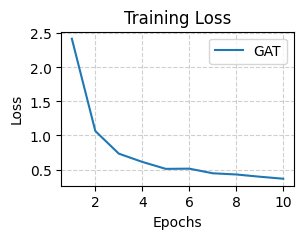

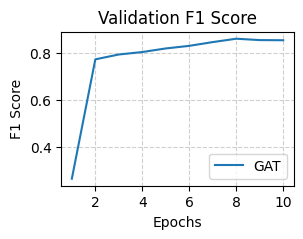

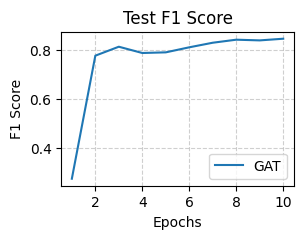

In [27]:
gat_run()

In [28]:
from GCN2 import GCN2

In [46]:
args = {
      'device': device,
      'num_layers': 10,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.001,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [30]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


Training GCN
Epoch: 001, Loss: 2.0596, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 002, Loss: 2.0008, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 003, Loss: 1.9667, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 004, Loss: 1.9032, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 005, Loss: 1.8696, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 006, Loss: 1.8092, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 007, Loss: 1.7619, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 008, Loss: 1.7794, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 009, Loss: 1.7004, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 010, Loss: 1.6606, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 011, Loss: 1.6076, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 012, Loss: 1.5640, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 013, Loss: 1.5620, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 014, Loss: 1.4906, Val F1: 0.0686,Val Acc: 0.3160, Time: 0.02s
Epoch: 

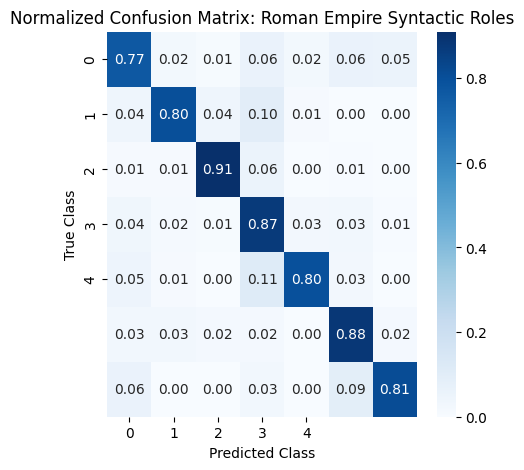

GCN2 results saved using PyG features.
Training Time 6.536785125732422


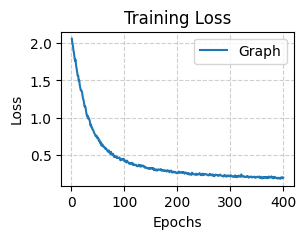

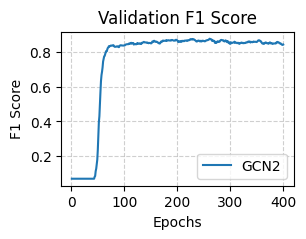

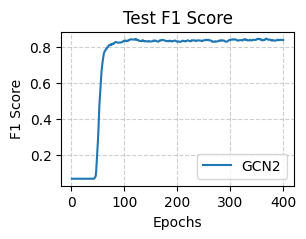

In [47]:
gcn2_run()

In [32]:
from H2GCN import H2GCN

In [39]:
args = {
      'device': device,
      'num_layers': 2, #Not applicable to H2GCN
      'hidden_dim': 30,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 30,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [40]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 001, Loss: 1.9712, Val F1: 0.2410,Val Acc: 0.4100, Time: 0.01s
Epoch: 002, Loss: 1.6633, Val F1: 0.3105,Val Acc: 0.4640, Time: 0.00s
Epoch: 003, Loss: 1.4009, Val F1: 0.3923,Val Acc: 0.5420, Time: 0.00s
Epoch: 004, Loss: 1.1652, Val F1: 0.4731,Val Acc: 0.6160, Time: 0.00s
Epoch: 005, Loss: 0.9591, Val F1: 0.5335,Val Acc: 0.6740, Time: 0.00s
Epoch: 006, Loss: 0.7901, Val F1: 0.6107,Val Acc: 0.7220, Time: 0.00s
Epoch: 007, Loss: 0.6585, Val F1: 0.6345,Val Acc: 0.7360, Time: 0.00s
Epoch: 008, Loss: 0.5481, Val F1: 0.7007,Val Acc: 0.7640, Time: 0.00s
Epoch: 009, Loss: 0.4630, Val F1: 0.7087,Val Acc: 0.7700, Time: 0.00s
Epoch: 010, Loss: 0.3805, Val F1: 0.7454,Val Acc: 0.7860, Time: 0.00s
Epoch: 011, Loss: 0.3237, Val F1: 0.7644,Val Acc: 0.7980, Time: 0.00s
Epoch: 012, Loss: 0.2729, Val F1: 0.7729,Val Acc: 0.8060, Time: 0.00s
Epoch: 013, Loss: 0.2304, Val F1: 0.7675,Val Acc: 0.8000, Time: 0.00s
Epoch: 014, Loss: 0.1924, Val F1: 0.7819,Val Acc: 0.8100, Time: 0.00s
Epoch

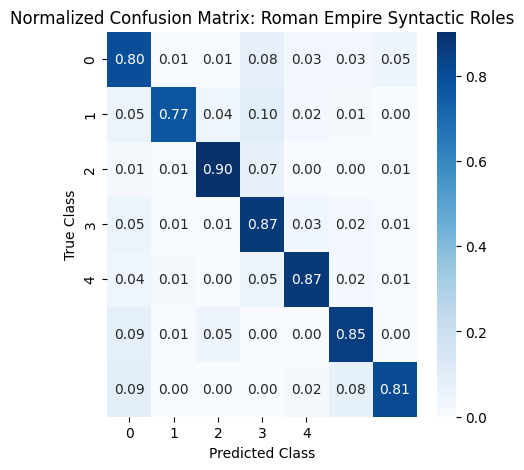

H2GCN results saved using PyG features.
Training Time 0.12650084495544434


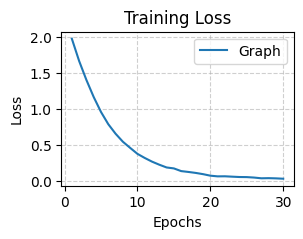

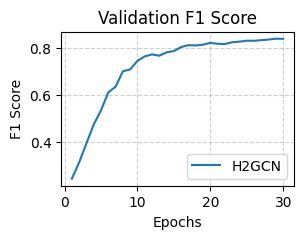

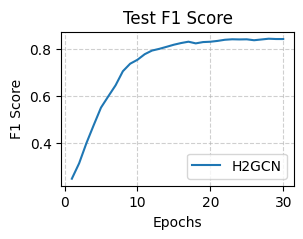

In [41]:
h2GCN_run()